# Cyberbullying Detection — Fine-tuned DistilBERT (Training + Testing in one notebook)

This version fine-tunes `distilbert-base-uncased` itself for classification (instead of freezing it and training a separate MLP head). Everything — training, evaluation, saving, and standalone testing on a new CSV — lives in this single notebook. Run top to bottom.

**Overfitting controls used here:** dropout inside DistilBERT's config, weight decay, a linear warmup+decay LR schedule, gradient clipping, and early stopping on validation loss (the best checkpoint is restored, not the last epoch). Optionally you can freeze the lower transformer layers (`freeze_n_layers` in CONFIG) so fewer parameters are being fit to your (likely smaller) dataset.

## 0. Install requirements (run once)

In [1]:
!pip install transformers torch pandas numpy matplotlib seaborn tqdm scikit-learn emoji joblib --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.6 MB/s eta 0:00:00


## 1. Imports

In [2]:
import re
import os
import json
import random
import emoji
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    DistilBertConfig,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

sns.set_style("whitegrid")

## 2. Config

Self-contained — no cell-order dependencies. Edit paths/hyperparameters here.

In [5]:
CONFIG = {
    "data_path": "/content/cyberbullying_tweets_with_sentiment_emoji.csv",
    "text_column": "tweet_text",
    "label_column": "cyberbullying_type",
    "model_name": "distilbert-base-uncased",
    "max_length": 64,
    "batch_size": 16,
    "eval_batch_size": 32,
    "epochs": 8,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "dropout": 0.2,               # hidden layer dropout inside DistilBERT
    "attention_dropout": 0.2,
    "seq_classif_dropout": 0.3,   # dropout on the classification head
    "freeze_n_layers": 0,         # 0-6; freeze the first N of DistilBERT's 6 transformer layers
    "label_smoothing": 0.05,
    "early_stopping_patience": 3,
    "test_size": 0.15,
    "val_size": 0.15,
    "seed": 42,
    "model_dir": "distilbert_cyberbullying_finetuned",
    "label_encoder_out": "label_encoder.joblib",
    "run_config_out": "run_config.json",
    "confusion_matrix_out": "confusion_matrix.png",
    "training_curves_out": "training_curves.png",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
torch.cuda.manual_seed_all(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# PART 1 — TRAINING

## 3. Load & clean data

In [6]:
def convert_emoji(text: str) -> str:
    text = emoji.demojize(text)
    text = text.replace(":", " ").replace("_", " ")
    return text


def clean_text(text: str) -> str:
    text = convert_emoji(str(text))
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df = pd.read_csv(CONFIG["data_path"])
df = df.dropna(subset=[CONFIG["text_column"], CONFIG["label_column"]]).reset_index(drop=True)
df["clean_text"] = df[CONFIG["text_column"]].apply(clean_text)
print(df.shape)
df[CONFIG["label_column"]].value_counts()

(47692, 3)


,count
cyberbullying_type,
religion,7998
age,7992
gender,7973
ethnicity,7961
not_cyberbullying,7945
other_cyberbullying,7823


## 4. Encode labels, split train/val/test

In [7]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df[CONFIG["label_column"]])
class_names = list(label_encoder.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

train_full_df, test_df = train_test_split(
    df, test_size=CONFIG["test_size"], stratify=df["label_id"], random_state=CONFIG["seed"]
)
train_df, val_df = train_test_split(
    train_full_df, test_size=CONFIG["val_size"], stratify=train_full_df["label_id"], random_state=CONFIG["seed"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_df["label_id"]), y=train_df["label_id"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(class_names, class_weights.cpu().numpy().round(3))))

Classes: ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']
Train: 34457 Val: 6081 Test: 7154
Class weights: {'age': np.float32(0.995), 'ethnicity': np.float32(0.998), 'gender': np.float32(0.997), 'not_cyberbullying': np.float32(1.0), 'other_cyberbullying': np.float32(1.016), 'religion': np.float32(0.994)}


## 5. Tokenizer, Dataset, DataLoader

In [8]:
tokenizer = DistilBertTokenizerFast.from_pretrained(CONFIG["model_name"])


class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_ds = TweetDataset(train_df["clean_text"].tolist(), train_df["label_id"].tolist(), tokenizer, CONFIG["max_length"])
val_ds = TweetDataset(val_df["clean_text"].tolist(), val_df["label_id"].tolist(), tokenizer, CONFIG["max_length"])
test_ds = TweetDataset(test_df["clean_text"].tolist(), test_df["label_id"].tolist(), tokenizer, CONFIG["max_length"])

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["eval_batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG["eval_batch_size"], shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## 6. Load DistilBERT for sequence classification

Dropout is raised above the HF defaults, and the lower N transformer layers can be frozen via `CONFIG["freeze_n_layers"]` — both reduce how much the model can overfit a small/noisy dataset.

In [9]:
bert_config = DistilBertConfig.from_pretrained(
    CONFIG["model_name"],
    num_labels=num_classes,
    dropout=CONFIG["dropout"],
    attention_dropout=CONFIG["attention_dropout"],
    seq_classif_dropout=CONFIG["seq_classif_dropout"],
)

model = DistilBertForSequenceClassification.from_pretrained(
    CONFIG["model_name"], config=bert_config
).to(device)

if CONFIG["freeze_n_layers"] > 0:
    for param in model.distilbert.embeddings.parameters():
        param.requires_grad = False
    for layer in model.distilbert.transformer.layer[: CONFIG["freeze_n_layers"]]:
        for param in layer.parameters():
            param.requires_grad = False
    print(f"Froze embeddings + first {CONFIG['freeze_n_layers']} transformer layer(s).")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 66,958,086 / 66,958,086


## 7. Optimizer, LR schedule, loss

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CONFIG["label_smoothing"])

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"],
)

total_steps = len(train_loader) * CONFIG["epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

## 8. Train with early stopping

In [11]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            if train_mode:
                optimizer.zero_grad()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * input_ids.size(0)
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            total += input_ids.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0
best_state = None

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= CONFIG["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.load_state_dict(best_state)

  0%|          | 0/2154 [00:00<?, ?it/s]

  0%|          | 0/191 [00:00<?, ?it/s]

Epoch 01 | train_loss 0.8530 acc 0.7282 | val_loss 0.5840 acc 0.8410


  0%|          | 0/2154 [00:00<?, ?it/s]

  0%|          | 0/191 [00:00<?, ?it/s]

...

Epoch 05 | train_loss 0.4239 acc 0.9198 | val_loss 0.6063 acc 0.8555


  0%|          | 0/2154 [00:00<?, ?it/s]

  0%|          | 0/191 [00:00<?, ?it/s]

Epoch 06 | train_loss 0.3998 acc 0.9314 | val_loss 0.6510 acc 0.8482
Early stopping at epoch 6 (best val_loss=0.5497)


<All keys matched successfully>

## 9. Training curves

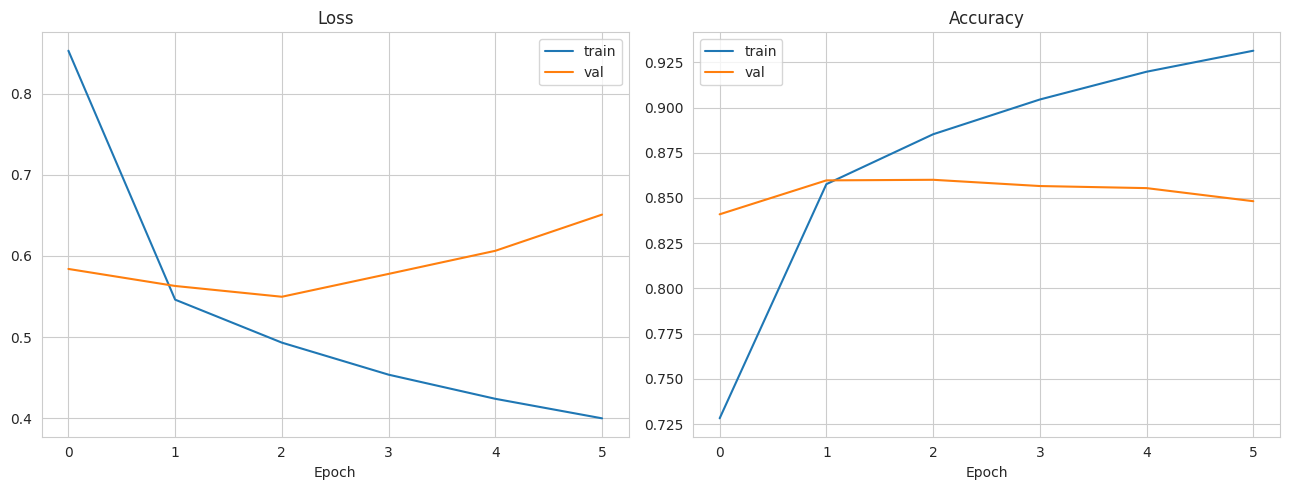

Final train/val accuracy gap: 0.0832 (large gap = overfitting warning sign)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(CONFIG["training_curves_out"], dpi=150)
plt.show()

gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"Final train/val accuracy gap: {gap:.4f} (large gap = overfitting warning sign)")

## 10. Evaluate on held-out test split

In [13]:
def predict_loader(loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(labels.numpy())
    return np.array(all_true), np.array(all_preds)


y_true, y_pred = predict_loader(test_loader)

test_acc = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average="macro")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1_macro:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names))

  0%|          | 0/224 [00:00<?, ?it/s]

Test accuracy: 0.8636
Test macro F1: 0.8596

                     precision    recall  f1-score   support

                age       0.98      0.98      0.98      1199
          ethnicity       0.98      0.97      0.98      1194
             gender       0.86      0.90      0.88      1196
  not_cyberbullying       0.77      0.53      0.63      1192
other_cyberbullying       0.65      0.83      0.73      1173
           religion       0.95      0.97      0.96      1200

           accuracy                           0.86      7154
          macro avg       0.87      0.86      0.86      7154
       weighted avg       0.87      0.86      0.86      7154



## 11. Confusion matrix

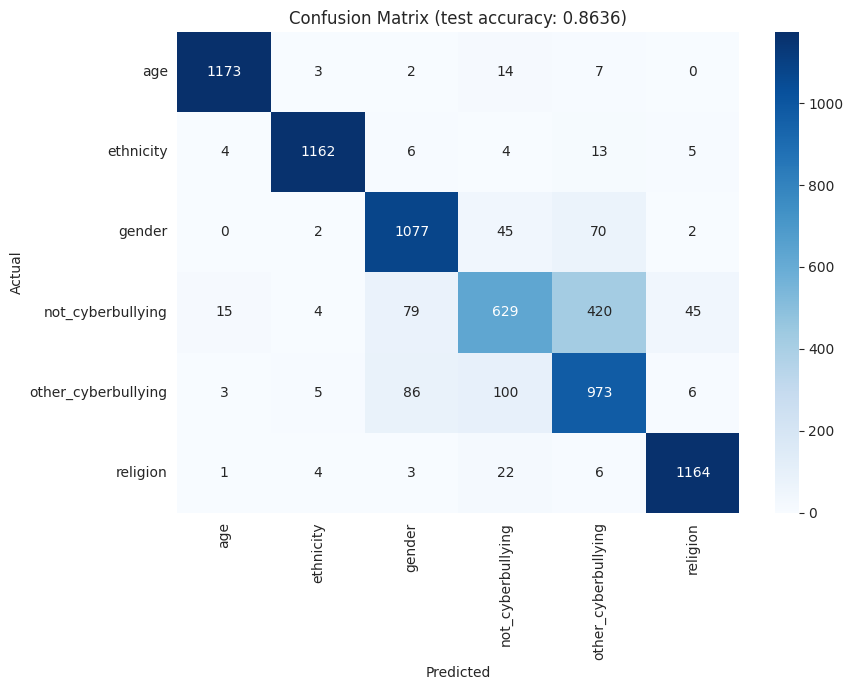

In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (test accuracy: {test_acc:.4f})")
plt.tight_layout()
plt.savefig(CONFIG["confusion_matrix_out"], dpi=150)
plt.show()

## 12. Save model, tokenizer, label encoder, config

In [15]:
os.makedirs(CONFIG["model_dir"], exist_ok=True)
model.save_pretrained(CONFIG["model_dir"])
tokenizer.save_pretrained(CONFIG["model_dir"])
joblib.dump(label_encoder, CONFIG["label_encoder_out"])

run_config_to_save = {
    "model_dir": CONFIG["model_dir"],
    "max_length": CONFIG["max_length"],
    "text_column": CONFIG["text_column"],
    "label_column": CONFIG["label_column"],
    "class_names": class_names,
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1_macro,
}
with open(CONFIG["run_config_out"], "w") as f:
    json.dump(run_config_to_save, f, indent=2)

print("Saved:")
print(" -", CONFIG["model_dir"] + "/ (model + tokenizer, via save_pretrained)")
print(" -", CONFIG["label_encoder_out"])
print(" -", CONFIG["run_config_out"])
print(" -", CONFIG["confusion_matrix_out"])
print(" -", CONFIG["training_curves_out"])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved:
 - distilbert_cyberbullying_finetuned/ (model + tokenizer, via save_pretrained)
 - label_encoder.joblib
 - run_config.json
 - confusion_matrix.png
 - training_curves.png


# PART 2 — STANDALONE TESTING

Everything below reloads from disk (`run_config.json`, the saved model folder, the label encoder) and only needs a CSV path — it does **not** depend on any variable from Part 1 above, so you can restart the kernel, run only this section, and it still works. Point `TEST_CSV_PATH` at any CSV with the same text column. A true-label column is optional.

## 13. Reload saved artifacts

In [19]:
TEST_CSV_PATH = "/content/cyberbullying_tweets_with_sentiment_emoji.csv"   # <-- change this to your test file
OUTPUT_PREDICTIONS_CSV = "predictions.csv"
OUTPUT_TEST_CONFUSION_MATRIX_PNG = "test_confusion_matrix.png"

with open("run_config.json") as f:
    test_run_config = json.load(f)

test_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_tokenizer = DistilBertTokenizerFast.from_pretrained(test_run_config["model_dir"])
test_model = DistilBertForSequenceClassification.from_pretrained(test_run_config["model_dir"]).to(test_device)
test_model.eval()

test_label_encoder = joblib.load("label_encoder.joblib")
print("Loaded model, tokenizer, and label encoder.")
print("Classes:", list(test_label_encoder.classes_))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded model, tokenizer, and label encoder.
Classes: ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']


## 14. Clean text (same function, redefined so this section is standalone)

In [20]:
def convert_emoji(text: str) -> str:
    text = emoji.demojize(text)
    text = text.replace(":", " ").replace("_", " ")
    return text


def clean_text(text: str) -> str:
    text = convert_emoji(str(text))
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

## 15. Load test CSV, clean, tokenize, predict

In [21]:
new_df = pd.read_csv(TEST_CSV_PATH)
text_col = test_run_config["text_column"]
label_col = test_run_config["label_column"]

assert text_col in new_df.columns, f"Expected a '{text_col}' column in {TEST_CSV_PATH}"
new_df = new_df.dropna(subset=[text_col]).reset_index(drop=True)
new_df["clean_text"] = new_df[text_col].apply(clean_text)

has_true_labels = label_col in new_df.columns
print("Has true labels for evaluation:", has_true_labels)

pred_ids_list, confidences = [], []
eval_batch_size = 32

with torch.no_grad():
    for i in tqdm(range(0, len(new_df), eval_batch_size)):
        batch_texts = new_df["clean_text"].iloc[i:i + eval_batch_size].tolist()
        encoded = test_tokenizer(
            batch_texts, truncation=True, max_length=test_run_config["max_length"],
            padding=True, return_tensors="pt",
        ).to(test_device)
        outputs = test_model(**encoded)
        probs = torch.softmax(outputs.logits, dim=1)
        batch_pred_ids = probs.argmax(1).cpu().numpy()
        batch_conf = probs.max(1).values.cpu().numpy()
        pred_ids_list.extend(batch_pred_ids)
        confidences.extend(batch_conf)

pred_ids_arr = np.array(pred_ids_list)
new_df["predicted_label"] = test_label_encoder.inverse_transform(pred_ids_arr)
new_df["confidence"] = confidences
new_df[[text_col, "predicted_label", "confidence"]].head(10)

Has true labels for evaluation: True


  0%|          | 0/1491 [00:00<?, ?it/s]

,tweet_text,predicted_label,confidence
0,"In other words #katandandre, your food was cra...",not_cyberbullying,0.834970
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,0.849121
2,@XochitlSuckkks a classy whore? Or more red ve...,gender,0.845391
3,"@Jason_Gio meh. :P thanks for the heads up, b...",other_cyberbullying,0.758051
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0.719609
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",not_cyberbullying,0.749467
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,not_cyberbullying,0.968319
7,Karma. I hope it bites Kat on the butt. She is...,gender,0.649679
8,@stockputout everything but mostly my priest ✨,other_cyberbullying,0.606410
9,Rebecca Black Drops Out of School Due to Bully...,not_cyberbullying,0.824408


## 16. If ground-truth labels exist: accuracy, report, confusion matrix

Accuracy: 0.8988

                     precision    recall  f1-score   support

                age       0.99      0.98      0.99      7992
          ethnicity       0.99      0.99      0.99      7961
             gender       0.91      0.93      0.92      7973
  not_cyberbullying       0.85      0.62      0.72      7945
other_cyberbullying       0.71      0.89      0.79      7823
           religion       0.97      0.98      0.97      7998

           accuracy                           0.90     47692
          macro avg       0.90      0.90      0.90     47692
       weighted avg       0.90      0.90      0.90     47692



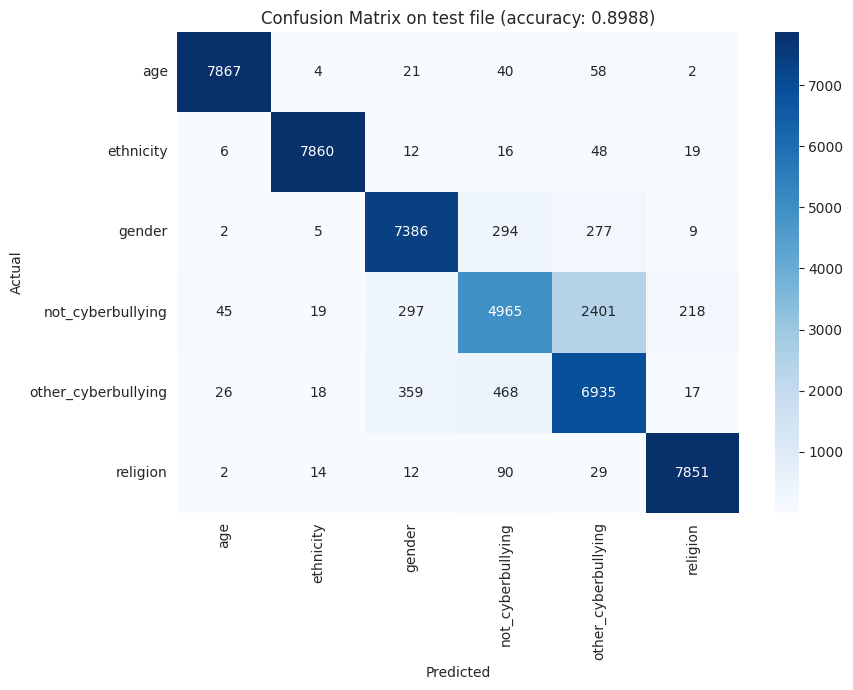

In [22]:
if has_true_labels:
    y_true_raw = new_df[label_col].values
    known_mask = np.isin(y_true_raw, test_label_encoder.classes_)
    if not known_mask.all():
        print(f"Warning: {(~known_mask).sum()} rows have labels unseen during training and are excluded from scoring.")

    y_true_new = test_label_encoder.transform(y_true_raw[known_mask])
    y_pred_new = pred_ids_arr[known_mask]
    new_class_names = list(test_label_encoder.classes_)

    acc = accuracy_score(y_true_new, y_pred_new)
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_true_new, y_pred_new, target_names=new_class_names))

    cm_new = confusion_matrix(y_true_new, y_pred_new)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_new, annot=True, fmt="d", cmap="Blues",
                xticklabels=new_class_names, yticklabels=new_class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix on test file (accuracy: {acc:.4f})")
    plt.tight_layout()
    plt.savefig(OUTPUT_TEST_CONFUSION_MATRIX_PNG, dpi=150)
    plt.show()
else:
    print("No ground-truth label column found — skipping accuracy/confusion matrix, predictions only.")

## 17. Save predictions

In [23]:
new_df.to_csv(OUTPUT_PREDICTIONS_CSV, index=False)
print("Saved predictions to:", OUTPUT_PREDICTIONS_CSV)

Saved predictions to: predictions.csv


In [25]:
!zip -r trained_llm_full.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.08.24/ (stored 0%)
  adding: content/.config/logs/2026.08.24/13.28.00.267545.log (deflated 58%)
  adding: content/.config/logs/2026.08.24/13.27.54.687874.log (deflated 58%)
  adding: content/.config/logs/2026.08.24/13.28.00.789021.log (deflated 56%)
  adding: content/.config/logs/2026.08.24/13.27.48.254038.log (deflated 58%)
  adding: content/.config/logs/2026.08.24/13.27.53.584308.log 

In [26]:
from google.colab import files

# Replace with your actual zip file path if it is different
files.download('/content/trained_llm.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Replace with your actual zip file path if it is different
files.download('/content/trained_llm_full.zip')